## Second-Phase Structural Models for End-to-End Evaluation

This notebook trains separate XGBoost regressors for `Grain_2`,
`a_2`, `b_2`, and `c_2` using the fixed structural training pools
and Li-air outer-test datasets.

### Workflow

1. Load structural training pools and matching outer-test records.
2. Select features using the training data.
3. Perform five-fold compound-grouped cross-validation.
4. Fit final models and evaluate training and outer-test predictions.
5. Save models, selected feature names, and prediction scatter data.

`Grain_2` uses log1p-transformed targets during training and is
converted back to the original scale for exported scatter data.
The `a_2`, `b_2`, and `c_2` models use their original target scales.

Feature selection is performed before cross-validation.
Saved training predictions are in-sample rather than out-of-fold.
Complete each target section sequentially before switching targets.

## 1. grain2

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
# ============================================================
# 1. Load the fixed training and outer-test datasets
# ============================================================

train_data = pd.read_csv(
    "data/end_to_end_split/structure/Grain2_train_pool.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_split/structure/Grain2_air_test.csv"
)

TARGET_COL = "Grain_2"
GROUP_COL = "compound"

In [3]:
# ============================================================
# 2. Define features, target, and groups
# ============================================================

X_train = train_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

# y_train = train_data[TARGET_COL].astype(float)

X_test = test_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

# y_test = test_data[TARGET_COL].astype(float)

groups_train = train_data[GROUP_COL]



y_train_raw = train_data[TARGET_COL].astype(float)
y_test_raw = test_data[TARGET_COL].astype(float)

y_train = np.log1p(y_train_raw)
y_test = np.log1p(y_test_raw)


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)

print(
    "Training compounds:",
    train_data[GROUP_COL].nunique()
)

print(
    "Outer-test compounds:",
    test_data[GROUP_COL].nunique()
)


Training shape: (47, 25)
Outer-test shape: (8, 25)
Training compounds: 47
Outer-test compounds: 8


In [4]:
# ============================================================
# 3. Feature selection
# ============================================================

fs_est = XGBRegressor(
    n_estimators=8,
    random_state=2027,
    verbosity=0,
    learning_rate=0.01,
#     max_depth=2,
)

fs_est.fit(
    X_train,
    y_train
)

importances = fs_est.feature_importances_

feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

selected_features = (
    
    feat_df
    .head(15)["feature"]
    .tolist()
)

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

Number of selected features: 15
Selected features: ['C_AW', 'AB_CR', 'AB_AN', 'C_AN', 'C_Nv', 'C_Np', 'C_EN', 'C_EA', 'C_SIE', 'C_FIE', 'C_VR', 'C_AR', 'C_CR', 'AB_TC', 'AB_AW']


In [5]:
# ============================================================
# 4. Define the regression model
# ============================================================

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=12,
    random_seed=2027,
)


In [6]:
# 5. Evaluation function
# ============================================================

def evaluate_regression(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return (
        f"MSE: {mse:.4f}  "
        f"RMSE: {rmse:.4f}  "
        f"MAE: {mae:.4f}  "
        f"R2: {r2:.4f}"
    )

In [7]:
# ============================================================
# 6. Grouped five-fold cross-validation
# ============================================================

group_cv = GroupKFold(
    n_splits=5
)

scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    X_train[selected_features],
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring=scoring,
    return_train_score=False
)

fold_mse = -cv_results["test_MSE"]
fold_rmse = np.sqrt(fold_mse)
fold_mae = -cv_results["test_MAE"]
fold_r2 = cv_results["test_R2"]

print("\n5-fold grouped CV:")

print(
    f"MSE: {fold_mse.mean():.4f} "
    f"± {fold_mse.std():.4f}"
)

print(
    f"RMSE: {fold_rmse.mean():.4f} "
    f"± {fold_rmse.std():.4f}"
)

print(
    f"MAE: {fold_mae.mean():.4f} "
    f"± {fold_mae.std():.4f}"
)

print(
    f"R2: {fold_r2.mean():.4f} "
    f"± {fold_r2.std():.4f}"
)


5-fold grouped CV:
MSE: 0.6578 ± 0.3139
RMSE: 0.7817 ± 0.2160
MAE: 0.6423 ± 0.1992
R2: -0.0471 ± 0.5086


In [8]:
# ============================================================
# 7. Train the final model
# ============================================================

model.fit(
    X_train[selected_features],
    y_train
)


# ============================================================
# 8. Predict the training and outer-test datasets
# ============================================================

y_train_pred = model.predict(
    X_train[selected_features]
)

y_test_pred = model.predict(
    X_test[selected_features]
)

print("\nTrain:")
print(
    evaluate_regression(
        y_train,
        y_train_pred
    )
)

print("\nOuter test:")
print(
    evaluate_regression(
        y_test,
        y_test_pred
    )
)


Train:
MSE: 0.0329  RMSE: 0.1815  MAE: 0.1171  R2: 0.9613

Outer test:
MSE: 0.0465  RMSE: 0.2157  MAE: 0.1871  R2: 0.8153


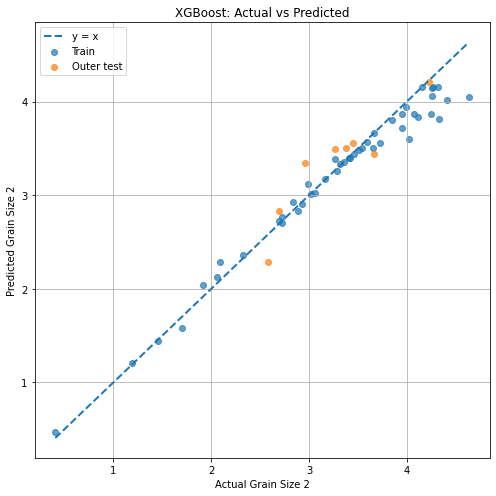

In [9]:
# ============================================================
# 9. Plot actual versus predicted values
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test,
    y_test_pred,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train.min(),
    y_test.min(),
    y_train_pred.min(),
    y_test_pred.min()
)

max_val = max(
    y_train.max(),
    y_test.max(),
    y_train_pred.max(),
    y_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual Grain Size 2")
plt.ylabel("Predicted Grain Size 2")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


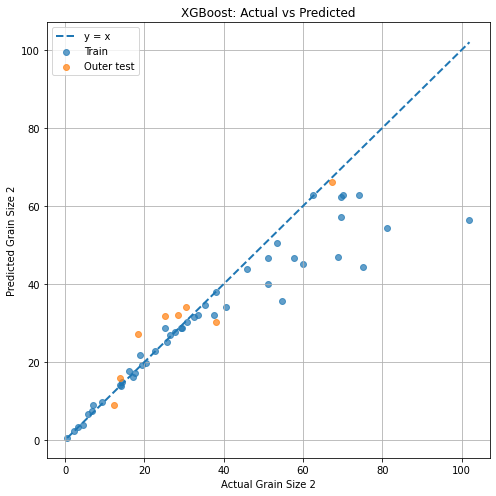

In [10]:
# ============================================================
# 9. Plot actual versus predicted values on the original scale
# ============================================================

# Convert log-transformed values back to the original scale
y_train_original = np.expm1(
    np.asarray(y_train)
)

y_test_original = np.expm1(
    np.asarray(y_test)
)

y_train_pred_original = np.expm1(
    np.asarray(y_train_pred)
)

y_test_pred_original = np.expm1(
    np.asarray(y_test_pred)
)


plt.figure(figsize=(7, 7))

plt.scatter(
    y_train_original,
    y_train_pred_original,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test_original,
    y_test_pred_original,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train_original.min(),
    y_test_original.min(),
    y_train_pred_original.min(),
    y_test_pred_original.min()
)

max_val = max(
    y_train_original.max(),
    y_test_original.max(),
    y_train_pred_original.max(),
    y_test_pred_original.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual Grain Size 2")
plt.ylabel("Predicted Grain Size 2")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
os.makedirs("model/end to end", exist_ok=True)

# Save model
joblib.dump(model, "model/end to end/xgb_Grain2.pkl")

# Save selected feature names
np.save(
    "model/end to end/Grain2_selected_features.npy",
    np.array(selected_features)
)

# Predictions on log scale
y_train_pred_log = model.predict(
    X_train[selected_features]
)

y_test_pred_log = model.predict(
    X_test[selected_features]
)

# Convert actual and predicted values to the original scale
y_train_original = np.expm1(
    np.asarray(y_train)
)

y_test_original = np.expm1(
    np.asarray(y_test)
)

y_train_pred_original = np.expm1(
    y_train_pred_log
)

y_test_pred_original = np.expm1(
    y_test_pred_log
)

# Save scatter plot data on the original scale
scatter_data = pd.concat([
    pd.DataFrame({
        "compound": train_data[GROUP_COL].to_numpy(),
        "dataset": "Train",
        "actual": y_train_original,
        "predicted": y_train_pred_original
    }),
    pd.DataFrame({
        "compound": test_data[GROUP_COL].to_numpy(),
        "dataset": "Test",
        "actual": y_test_original,
        "predicted": y_test_pred_original
    })
], ignore_index=True)

scatter_data.to_csv(
    "model/end to end/Grain2_scatter_data_original.csv",
    index=False
)

print("Model, selected features, and original-scale scatter data were saved.")

Model, selected features, and original-scale scatter data were saved.


## 2.a2

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
# ============================================================
# 1. Load the fixed training and outer-test datasets
# ============================================================

train_data = pd.read_csv(
    "data/end_to_end_split/structure/a2_train_pool.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_split/structure/a2_air_test.csv"
)

TARGET_COL = "a_2"
GROUP_COL = "compound"

In [3]:
# ============================================================
# 2. Define features, target, and groups
# ============================================================

X_train = train_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_train = train_data[TARGET_COL].astype(float)

X_test = test_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_test = test_data[TARGET_COL].astype(float)

groups_train = train_data[GROUP_COL]



# y_train_raw = train_data[TARGET_COL].astype(float)
# y_test_raw = test_data[TARGET_COL].astype(float)

# y_train = np.log1p(y_train_raw)
# y_test = np.log1p(y_test_raw)


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)

print(
    "Training compounds:",
    train_data[GROUP_COL].nunique()
)

print(
    "Outer-test compounds:",
    test_data[GROUP_COL].nunique()
)


Training shape: (47, 25)
Outer-test shape: (8, 25)
Training compounds: 47
Outer-test compounds: 8


In [4]:
# ============================================================
# 3. Feature selection
# ============================================================

fs_est = XGBRegressor(
    n_estimators=150,
    random_state=42,
    verbosity=1,
    learning_rate=0.01,
    tree_method="hist"
)

fs_est.fit(
    X_train,
    y_train
)

importances = fs_est.feature_importances_

feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

selected_features = (
    feat_df
    .head(12)["feature"]
    .tolist()
)

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

Number of selected features: 12
Selected features: ['C_EA', 'C_AN', 'AB_EN', 'AB_Nd', 'AB_FIE', 'AB_Nv', 'AB_EA', 'AB_CR', 'AB_SIE', 'AB_EC', 'AB_AN', 'C_SIE']


In [5]:
# ============================================================
# 4. Define the regression model
# ============================================================

model = XGBRegressor(
    objective='reg:squarederror',  # Regression objective
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    colsample_bytree=0.8,
    gamma=0.5,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=5,
    subsample=0.75,
    random_state=2027
)


In [6]:
# 5. Evaluation function
# ============================================================

def evaluate_regression(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return (
        f"MSE: {mse:.4f}  "
        f"RMSE: {rmse:.4f}  "
        f"MAE: {mae:.4f}  "
        f"R2: {r2:.4f}"
    )

In [7]:
# ============================================================
# 6. Grouped five-fold cross-validation
# ============================================================

group_cv = GroupKFold(
    n_splits=5
)

scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    X_train[selected_features],
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring=scoring,
    return_train_score=False
)

fold_mse = -cv_results["test_MSE"]
fold_rmse = np.sqrt(fold_mse)
fold_mae = -cv_results["test_MAE"]
fold_r2 = cv_results["test_R2"]

print("\n5-fold grouped CV:")

print(
    f"MSE: {fold_mse.mean():.4f} "
    f"± {fold_mse.std():.4f}"
)

print(
    f"RMSE: {fold_rmse.mean():.4f} "
    f"± {fold_rmse.std():.4f}"
)

print(
    f"MAE: {fold_mae.mean():.4f} "
    f"± {fold_mae.std():.4f}"
)

print(
    f"R2: {fold_r2.mean():.4f} "
    f"± {fold_r2.std():.4f}"
)


5-fold grouped CV:
MSE: 1.7656 ± 0.8489
RMSE: 1.2957 ± 0.2944
MAE: 0.9791 ± 0.2408
R2: 0.5974 ± 0.1718


In [8]:
# ============================================================
# 7. Train the final model
# ============================================================

model.fit(
    X_train[selected_features],
    y_train
)


# ============================================================
# 8. Predict the training and outer-test datasets
# ============================================================

y_train_pred = model.predict(
    X_train[selected_features]
)

y_test_pred = model.predict(
    X_test[selected_features]
)

print("\nTrain:")
print(
    evaluate_regression(
        y_train,
        y_train_pred
    )
)

print("\nOuter test:")
print(
    evaluate_regression(
        y_test,
        y_test_pred
    )
)


Train:
MSE: 0.1836  RMSE: 0.4285  MAE: 0.3237  R2: 0.9599

Outer test:
MSE: 1.3539  RMSE: 1.1636  MAE: 0.9656  R2: 0.8151


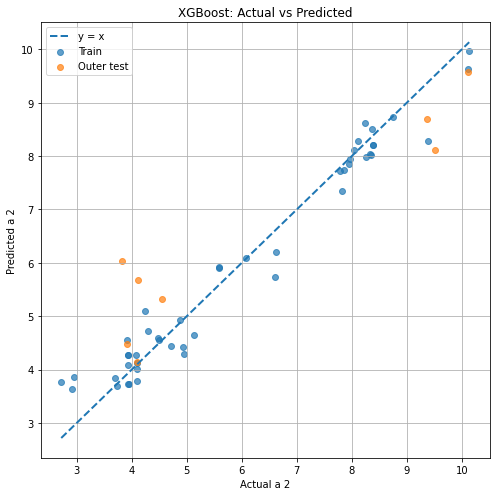

In [9]:
# ============================================================
# 9. Plot actual versus predicted values
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test,
    y_test_pred,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train.min(),
    y_test.min(),
    y_train_pred.min(),
    y_test_pred.min()
)

max_val = max(
    y_train.max(),
    y_test.max(),
    y_train_pred.max(),
    y_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual a 2")
plt.ylabel("Predicted a 2")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
os.makedirs("model/end to end", exist_ok=True)

# Save model
joblib.dump(model, "model/end to end/xgb_a2.pkl")

# Save selected feature names
np.save(
    "model/end to end/a2_selected_features.npy",
    np.array(selected_features)
)

# Predictions on the original target scale
y_train_pred_log = model.predict(X_train[selected_features])
y_test_pred_log = model.predict(X_test[selected_features])

# Save scatter plot data
scatter_data = pd.concat([
    pd.DataFrame({
        "compound": train_data[GROUP_COL],
        "dataset": "Train",
        "actual": y_train,
        "predicted": y_train_pred_log
    }),
    pd.DataFrame({
        "compound": test_data[GROUP_COL],
        "dataset": "Test",
        "actual": y_test,
        "predicted": y_test_pred_log
    })
], ignore_index=True)

scatter_data.to_csv(
    "model/end to end/a2_scatter_data.csv",
    index=False
)

print("Model, selected features, and scatter data were saved.")

Model, selected features, and scatter data were saved.


## 3. b2

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
# ============================================================
# 1. Load the fixed training and outer-test datasets
# ============================================================

train_data = pd.read_csv(
    "data/end_to_end_split/structure/b2_train_pool.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_split/structure/b2_air_test.csv"
)

TARGET_COL = "b_2"
GROUP_COL = "compound"

In [3]:
# ============================================================
# 2. Define features, target, and groups
# ============================================================

X_train = train_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_train = train_data[TARGET_COL].astype(float)

X_test = test_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_test = test_data[TARGET_COL].astype(float)

groups_train = train_data[GROUP_COL]



# y_train_raw = train_data[TARGET_COL].astype(float)
# y_test_raw = test_data[TARGET_COL].astype(float)

# y_train = np.log1p(y_train_raw)
# y_test = np.log1p(y_test_raw)


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)

print(
    "Training compounds:",
    train_data[GROUP_COL].nunique()
)

print(
    "Outer-test compounds:",
    test_data[GROUP_COL].nunique()
)


Training shape: (47, 25)
Outer-test shape: (8, 25)
Training compounds: 47
Outer-test compounds: 8


In [4]:
# ============================================================
# 3. Feature selection
# ============================================================

fs_est = XGBRegressor(
    n_estimators=80,
    random_state=42,
    verbosity=1,
    learning_rate=0.05,
    tree_method="hist"
)

fs_est.fit(
    X_train,
    y_train
)

importances = fs_est.feature_importances_

feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

selected_features = (
    feat_df
    .head(10)["feature"]
    .tolist()
)

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

Number of selected features: 10
Selected features: ['C_EA', 'AB_EN', 'C_AN', 'AB_Nv', 'AB_Nd', 'AB_EA', 'AB_CR', 'AB_EC', 'AB_FIE', 'AB_D']


In [5]:
# ============================================================
# 4. Define the regression model
# ============================================================

model = XGBRegressor(
    objective='reg:squarederror',  # Regression objective
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    colsample_bytree=0.8,
    gamma=0.5,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=5,
    subsample=0.75,
    random_state=42
)


In [6]:
# 5. Evaluation function
# ============================================================

def evaluate_regression(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return (
        f"MSE: {mse:.4f}  "
        f"RMSE: {rmse:.4f}  "
        f"MAE: {mae:.4f}  "
        f"R2: {r2:.4f}"
    )

In [7]:
# ============================================================
# 6. Grouped five-fold cross-validation
# ============================================================

group_cv = GroupKFold(
    n_splits=5
)

scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    X_train[selected_features],
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring=scoring,
    return_train_score=False
)

fold_mse = -cv_results["test_MSE"]
fold_rmse = np.sqrt(fold_mse)
fold_mae = -cv_results["test_MAE"]
fold_r2 = cv_results["test_R2"]

print("\n5-fold grouped CV:")

print(
    f"MSE: {fold_mse.mean():.4f} "
    f"± {fold_mse.std():.4f}"
)

print(
    f"RMSE: {fold_rmse.mean():.4f} "
    f"± {fold_rmse.std():.4f}"
)

print(
    f"MAE: {fold_mae.mean():.4f} "
    f"± {fold_mae.std():.4f}"
)

print(
    f"R2: {fold_r2.mean():.4f} "
    f"± {fold_r2.std():.4f}"
)


5-fold grouped CV:
MSE: 1.6078 ± 1.0644
RMSE: 1.2066 ± 0.3898
MAE: 0.8991 ± 0.2644
R2: 0.6321 ± 0.2230


In [8]:
# ============================================================
# 7. Train the final model
# ============================================================

model.fit(
    X_train[selected_features],
    y_train
)


# ============================================================
# 8. Predict the training and outer-test datasets
# ============================================================

y_train_pred = model.predict(
    X_train[selected_features]
)

y_test_pred = model.predict(
    X_test[selected_features]
)

print("\nTrain:")
print(
    evaluate_regression(
        y_train,
        y_train_pred
    )
)

print("\nOuter test:")
print(
    evaluate_regression(
        y_test,
        y_test_pred
    )
)


Train:
MSE: 0.2143  RMSE: 0.4629  MAE: 0.3477  R2: 0.9524

Outer test:
MSE: 0.8679  RMSE: 0.9316  MAE: 0.7986  R2: 0.8714


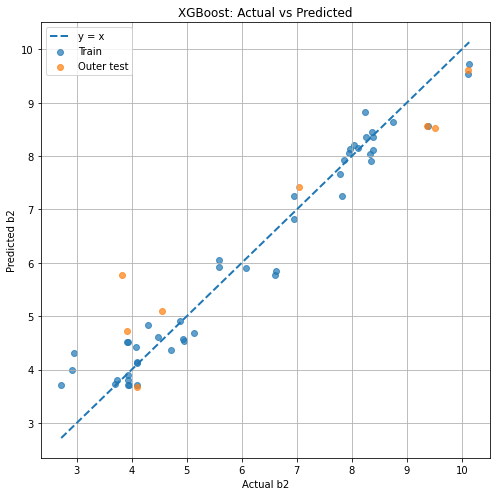

In [9]:
# ============================================================
# 9. Plot actual versus predicted values
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test,
    y_test_pred,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train.min(),
    y_test.min(),
    y_train_pred.min(),
    y_test_pred.min()
)

max_val = max(
    y_train.max(),
    y_test.max(),
    y_train_pred.max(),
    y_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual b2")
plt.ylabel("Predicted b2")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
os.makedirs("model/end to end", exist_ok=True)

# Save model
joblib.dump(model, "model/end to end/xgb_b2.pkl")

# Save selected feature names
np.save(
    "model/end to end/b2_selected_features.npy",
    np.array(selected_features)
)

# Predictions on the original target scale
y_train_pred_log = model.predict(X_train[selected_features])
y_test_pred_log = model.predict(X_test[selected_features])

# Save scatter plot data
scatter_data = pd.concat([
    pd.DataFrame({
        "compound": train_data[GROUP_COL],
        "dataset": "Train",
        "actual": y_train,
        "predicted": y_train_pred_log
    }),
    pd.DataFrame({
        "compound": test_data[GROUP_COL],
        "dataset": "Test",
        "actual": y_test,
        "predicted": y_test_pred_log
    })
], ignore_index=True)

scatter_data.to_csv(
    "model/end to end/b2_scatter_data.csv",
    index=False
)

print("Model, selected features, and scatter data were saved.")

Model, selected features, and scatter data were saved.


## 4.c2

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
# ============================================================
# 1. Load the fixed training and outer-test datasets
# ============================================================

train_data = pd.read_csv(
    "data/end_to_end_split/structure/c2_train_pool.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_split/structure/c2_air_test.csv"
)

TARGET_COL = "c_2"
GROUP_COL = "compound"

In [3]:
# ============================================================
# 2. Define features, target, and groups
# ============================================================

X_train = train_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_train = train_data[TARGET_COL].astype(float)

X_test = test_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_test = test_data[TARGET_COL].astype(float)

groups_train = train_data[GROUP_COL]



# y_train_raw = train_data[TARGET_COL].astype(float)
# y_test_raw = test_data[TARGET_COL].astype(float)

# y_train = np.log1p(y_train_raw)
# y_test = np.log1p(y_test_raw)


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)

print(
    "Training compounds:",
    train_data[GROUP_COL].nunique()
)

print(
    "Outer-test compounds:",
    test_data[GROUP_COL].nunique()
)


Training shape: (47, 25)
Outer-test shape: (8, 25)
Training compounds: 47
Outer-test compounds: 8


In [4]:
# ============================================================
# 3. Feature selection
# ============================================================

fs_est = XGBRegressor(
    n_estimators=200,
    random_state=42,
    verbosity=0,
    tree_method="hist"
)

fs_est.fit(
    X_train,
    y_train
)

importances = fs_est.feature_importances_

feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

selected_features = (
    feat_df
    .head(8)["feature"]
    .tolist()
)

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

Number of selected features: 8
Selected features: ['C_AW', 'AB_EN', 'AB_Nd', 'AB_AN', 'AB_D', 'C_AN', 'AB_EA', 'AB_TC']


In [5]:
# ============================================================
# 4. Define the regression model
# ============================================================

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,        
    learning_rate=0.06,     
    max_depth=3,             
    min_child_weight=6,      
    gamma=0.1,               
    subsample=0.75,         
    colsample_bytree=0.65,  
    reg_alpha=0.3,           
    reg_lambda=10.0,         
    random_state=24,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)


In [6]:
# 5. Evaluation function
# ============================================================

def evaluate_regression(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return (
        f"MSE: {mse:.4f}  "
        f"RMSE: {rmse:.4f}  "
        f"MAE: {mae:.4f}  "
        f"R2: {r2:.4f}"
    )

In [7]:
# ============================================================
# 6. Grouped five-fold cross-validation
# ============================================================

group_cv = GroupKFold(
    n_splits=5
)

scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    X_train[selected_features],
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring=scoring,
    return_train_score=False
)

fold_mse = -cv_results["test_MSE"]
fold_rmse = np.sqrt(fold_mse)
fold_mae = -cv_results["test_MAE"]
fold_r2 = cv_results["test_R2"]

print("\n5-fold grouped CV:")

print(
    f"MSE: {fold_mse.mean():.4f} "
    f"± {fold_mse.std():.4f}"
)

print(
    f"RMSE: {fold_rmse.mean():.4f} "
    f"± {fold_rmse.std():.4f}"
)

print(
    f"MAE: {fold_mae.mean():.4f} "
    f"± {fold_mae.std():.4f}"
)

print(
    f"R2: {fold_r2.mean():.4f} "
    f"± {fold_r2.std():.4f}"
)


5-fold grouped CV:
MSE: 25.6819 ± 16.2433
RMSE: 4.8725 ± 1.3931
MAE: 3.0413 ± 0.5506
R2: -0.3493 ± 0.8709


In [8]:
# ============================================================
# 7. Train the final model
# ============================================================

model.fit(
    X_train[selected_features],
    y_train
)


# ============================================================
# 8. Predict the training and outer-test datasets
# ============================================================

y_train_pred = model.predict(
    X_train[selected_features]
)

y_test_pred = model.predict(
    X_test[selected_features]
)

print("\nTrain:")
print(
    evaluate_regression(
        y_train,
        y_train_pred
    )
)

print("\nOuter test:")
print(
    evaluate_regression(
        y_test,
        y_test_pred
    )
)


Train:
MSE: 2.7636  RMSE: 1.6624  MAE: 0.9722  R2: 0.9204

Outer test:
MSE: 0.8794  RMSE: 0.9378  MAE: 0.8334  R2: 0.8895


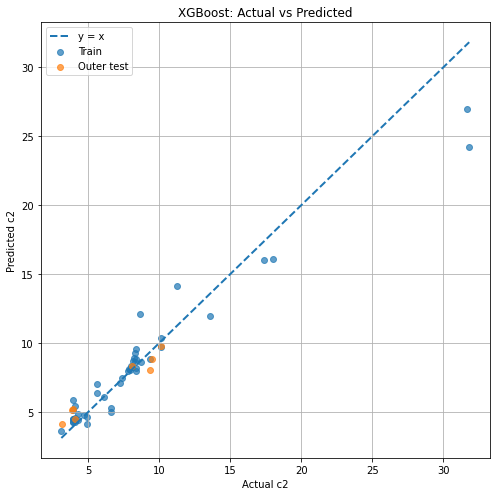

In [9]:
# ============================================================
# 9. Plot actual versus predicted values
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test,
    y_test_pred,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train.min(),
    y_test.min(),
    y_train_pred.min(),
    y_test_pred.min()
)

max_val = max(
    y_train.max(),
    y_test.max(),
    y_train_pred.max(),
    y_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual c2")
plt.ylabel("Predicted c2")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
os.makedirs("model/end to end", exist_ok=True)

# Save model
joblib.dump(model, "model/end to end/xgb_c2.pkl")

# Save selected feature names
np.save(
    "model/end to end/c2_selected_features.npy",
    np.array(selected_features)
)

# Predictions on the original target scale
y_train_pred_log = model.predict(X_train[selected_features])
y_test_pred_log = model.predict(X_test[selected_features])

# Save scatter plot data
scatter_data = pd.concat([
    pd.DataFrame({
        "compound": train_data[GROUP_COL],
        "dataset": "Train",
        "actual": y_train,
        "predicted": y_train_pred_log
    }),
    pd.DataFrame({
        "compound": test_data[GROUP_COL],
        "dataset": "Test",
        "actual": y_test,
        "predicted": y_test_pred_log
    })
], ignore_index=True)

scatter_data.to_csv(
    "model/end to end/c2_scatter_data.csv",
    index=False
)

print("Model, selected features, and scatter data were saved.")

Model, selected features, and scatter data were saved.
